# Modelo de finishers — árbol / random forest

Objetivo: predecir `finisher_d` y `finisher_h` (finishers mujer/hombre) de una categoría de
una carrera a partir de sus características (distancia, tipo de modalidad, público,
ubicación, población del municipio...) y, cuando exista, del historial de la propia carrera.

Decisiones tomadas antes de escribir código, siguiendo las notas finales de
`EDA_finishers_carreras.ipynb`:

- **Dos modelos separados** (uno para `finisher_d`, otro para `finisher_h`), no uno
  multi-output: la participación femenina se comporta de forma muy distinta según
  distancia/modalidad, así que tiene sentido poder ajustar cada modelo por separado.
- **Split train/test temporal, nunca por fila al azar**: la misma carrera en años
  consecutivos correlaciona al 0.90 en finishers (EDA, sección 4) — un split aleatorio
  dejaría la edición 2023 en train y la 2024 en test y el modelo parecería mucho mejor
  de lo que realmente es. Se entrena con años ≤ 2023 y se evalúa con 2024-2025 (2026 se
  excluye por ser el año en curso, con datos incompletos).
- **Parte de `DF_TODAS_UNION.csv`** (generado por `Limpieza_union.ipynb`), que ya trae año/mes/estación, `total_finishers`, `es_finde`, el cruce con población del INE y el índice `es_carrera_popular` calculados — aquí solo queda lo específico del modelo.
- **No se usa `Limpieza_outliers.ipynb`**: ese notebook decide, con razón, no recortar
  outliers para un árbol (son poco sensibles a la escala), así que como paso de "limpieza
  de outliers" no aporta nada aquí. Lo único útil que hacía — pasar el centinela
  `distancia == 0` a `NaN` — se repite más abajo directamente, porque no está disponible en
  `DF_TODAS_UNION.csv`.
- Se presta atención especial a la **población del municipio**: es la variable que, de
  forma aislada, más correlaciona con los objetivos en el EDA (aun así, por debajo de
  0.16), así que aquí no solo se incluye como feature — se comprueba su importancia real
  dentro del modelo entrenado, no se da por supuesta.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA_TODAS = Path("../../data/processed/union/DF_TODAS_UNION.csv")
df = pd.read_csv(RUTA_TODAS, encoding="utf-8-sig")
df["fecha"] = pd.to_datetime(df["fecha"])

print("Filas x columnas:", df.shape)
df.head()

Filas x columnas: (41544, 24)


,fuente,nombre_carrera,fecha,dia_semana,distancia,tipo_modalidad,publico,finisher_d,finisher_h,municipio,...,estacion,total_finishers,es_finde,municipio_norm,provincia_norm,provincia_ine,total_poblacion,poblacion_h,poblacion_d,es_carrera_popular
0,buscametas,Areta Trail Lasterketa,2026-07-25,Sábado,0.0,trail running,Absoluta/General,17.0,147.0,Areta,...,Verano,164.0,True,ARETA,ALAVA,1.0,NaN,NaN,NaN,False
1,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,0.0,Ciclismo y btt,Absoluta/General,0.0,30.0,Ezcaray,...,Verano,30.0,True,EZCARAY,LA RIOJA,26.0,2057.0,1057.0,1000.0,False
2,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,93.0,Ciclismo y btt,Absoluta/General,2.0,38.0,Ezcaray,...,Verano,40.0,True,EZCARAY,LA RIOJA,26.0,2057.0,1057.0,1000.0,False
3,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,57.0,Ciclismo y btt,Absoluta/General,2.0,31.0,Ezcaray,...,Verano,33.0,True,EZCARAY,LA RIOJA,26.0,2057.0,1057.0,1000.0,False
4,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,42.0,Ciclismo y btt,Absoluta/General,2.0,10.0,Ezcaray,...,Verano,12.0,True,EZCARAY,LA RIOJA,26.0,2057.0,1057.0,1000.0,False


## Variables derivadas y cruce con población

Ya vienen calculadas en `DF_TODAS_UNION.csv` (generado por `Limpieza_union.ipynb`): año, mes, estación, `total_finishers`, `es_finde`, el cruce con población del INE (`total_poblacion`, `poblacion_h`, `poblacion_d`) y el índice `es_carrera_popular`. No hace falta recalcular nada aquí.

## `distancia == 0` es un centinela, no un valor real

Igual que en `Limpieza_outliers.ipynb`: `distancia == 0` significa "no se pudo extraer
la distancia" en las 10 fuentes, no "carrera de 0 km". Se pasa a `NaN` y se guarda un
booleano `distancia_conocida` — el propio hecho de que la distancia se conozca o no
puede ser una señal (varía mucho por fuente/categoría) y así no se pierde esa
información al convertir a `NaN`. Se usa `np.nan`, no `pd.NA`, para que la columna se
quede en `float64`.

In [2]:
print("% de filas con distancia == 0, por fuente:")
print((df.groupby("fuente")["distancia"].apply(lambda s: (s == 0).mean() * 100)).round(1))

df["distancia_conocida"] = df["distancia"] != 0
df["distancia"] = df["distancia"].replace(0, np.nan)

print()
print("Filas con distancia ahora NaN:", df["distancia"].isna().sum(), "de", len(df))

% de filas con distancia == 0, por fuente:
fuente
buscametas          66.5
carreirasgalegas     1.1
ccnorte             65.7
championsxip        62.9
cronofinisher       80.2
cruzandolameta      23.0
cursescat            4.5
iter5               34.2
mychip              12.7
sportmaniacs        65.3
Name: distancia, dtype: float64

Filas con distancia ahora NaN: 21472 de 41544


### Población desconocida: imputar, no descartar

Descartar el 16.6% de filas sin población cruzada (ver `Limpieza_union.ipynb` para el porqué de ese resto) sería tirar datos reales solo por un problema de cruce. En vez de eso: se
guarda un booleano `poblacion_conocida` (para que el árbol pueda tratar distinto los
casos reales de los imputados) y se rellena el resto con la mediana global. Un
`RandomForestRegressor` de scikit-learn no admite `NaN` en los predictores, así que
alguna imputación es obligatoria pase lo que pase.

In [3]:
df["poblacion_conocida"] = df["total_poblacion"].notna()
mediana_poblacion = df["total_poblacion"].median()
df["total_poblacion"] = df["total_poblacion"].fillna(mediana_poblacion)

print(f"Población desconocida en {(~df['poblacion_conocida']).sum()} filas de {len(df)}, "
      f"imputada con la mediana global ({mediana_poblacion:,.0f} hab.)")

Población desconocida en 6010 filas de 41544, imputada con la mediana global (17,062 hab.)


También hay que imputar `distancia` (quedó en `NaN` donde antes había el
centinela `0`): se usa la mediana dentro de cada `tipo_modalidad`, porque la escala
típica es muy distinta entre disciplinas (una `Ciclismo y btt` y una `Infantil` no
tienen distancias comparables).

In [4]:
df["distancia"] = df.groupby("tipo_modalidad")["distancia"].transform(lambda s: s.fillna(s.median()))
df["distancia"] = df["distancia"].fillna(df["distancia"].median())  # por si algún grupo fuera 100% NaN

print("Nulos en distancia tras imputar:", df["distancia"].isna().sum())

Nulos en distancia tras imputar: 0


## El predictor más fuerte: el historial de la propia carrera

El EDA (sección 4) encontró una correlación de 0.90 entre los finishers de una carrera
un año y los del año anterior — con diferencia, la señal más fuerte de todo el
análisis, muy por encima de cualquier variable descriptiva. Aquí se construye ese
historial a nivel de fila (no solo de carrera): para cada `fuente` + carrera
(nombre normalizado, sin ordinal de edición ni año) + `publico`, se busca el valor de
`finisher_d`/`finisher_h` del año inmediatamente anterior (solo años consecutivos, para
no mezclar ediciones con un hueco de por medio).

In [5]:
def _normalizar_base(nombre):
    if pd.isna(nombre):
        return None
    t = unicodedata.normalize("NFKD", str(nombre)).encode("ascii", "ignore").decode("ascii").upper()
    t = re.sub(r"[^A-Z0-9]+", " ", t)
    t = re.sub(r"^\s*(?:[IVXLC]{1,6}|\d{1,3}(?:A|O|ER|ERA)?)\b\s*", "", t)  # ordinal inicial
    t = re.sub(r"\b(19|20)\d{2}\b", "", t)  # año suelto
    return re.sub(r"\s{2,}", " ", t).strip()


df["nombre_base"] = df["nombre_carrera"].apply(_normalizar_base)

CLAVE_CARRERA = ["fuente", "nombre_base", "publico"]
historico = (
    df[CLAVE_CARRERA + ["anyo", "finisher_d", "finisher_h"]]
    .dropna(subset=["finisher_d", "finisher_h"])
    .groupby(CLAVE_CARRERA + ["anyo"], as_index=False)[["finisher_d", "finisher_h"]]
    .sum()
    .sort_values(CLAVE_CARRERA + ["anyo"])
)
historico["anyo_anterior"] = historico.groupby(CLAVE_CARRERA)["anyo"].shift(1)
historico["finisher_d_anterior"] = historico.groupby(CLAVE_CARRERA)["finisher_d"].shift(1)
historico["finisher_h_anterior"] = historico.groupby(CLAVE_CARRERA)["finisher_h"].shift(1)
historico = historico[historico["anyo"] - historico["anyo_anterior"] == 1]

df = df.merge(
    historico[CLAVE_CARRERA + ["anyo", "finisher_d_anterior", "finisher_h_anterior"]],
    on=CLAVE_CARRERA + ["anyo"],
    how="left",
)
df["tiene_historial"] = df["finisher_d_anterior"].notna()

print(f"Filas con historial de la edición anterior (misma carrera y categoría): "
      f"{df['tiene_historial'].sum()} de {len(df)} ({100 * df['tiene_historial'].mean():.1f}%)")

Filas con historial de la edición anterior (misma carrera y categoría): 12115 de 41544 (29.2%)


## Para las carreras SIN historial: comparables por grupo similar, no la media global

El objetivo no es solo predecir bien las ediciones de carreras que ya conocemos —
sobre todo interesa poder predecir con confianza una **carrera nueva**. Ahí es
justo donde el modelo flaqueaba: sin historial propio, `finisher_d_anterior`/
`finisher_h_anterior` no tenían ningún valor real que ofrecer, y rellenarlos con
la mediana global (un solo número para las 41.650 filas) no distingue nada entre,
por ejemplo, una maratón de road running en Barcelona y una carrera infantil de
5 km en un pueblo pequeño.

En vez de eso: para cada fila se busca la mediana (en escala `log1p`, para no
dejarse arrastrar por los eventos gigantes) de `finisher_d`/`finisher_h` entre
carreras **comparables** — misma `tipo_modalidad` + `publico` + `provincia` +
tramo de `distancia` — y si ese grupo tiene muy pocas muestras, se retrocede a un
grupo más amplio (se quita primero `provincia`, luego `publico`, y en último caso
solo se exige `tipo_modalidad`). Los estadísticos de cada grupo se calculan
**solo con años de train (≤ 2023)**, y con *leave-one-out* dentro del propio train
(cada fila se compara con las demás de su grupo, nunca consigo misma) para no
inflar artificialmente su propia estimación — si no se hiciera así, una fila de
train "vería" su propio valor camuflado dentro de la media del grupo.

Se guarda también `nivel_comparable` (0 = coincidencia más específica, 4 =
solo hizo falta la disciplina): es una señal de cuánto fiarse de la estimación,
igual que `distancia_conocida`/`poblacion_conocida` más arriba.

In [6]:
DISTANCIA_BINS = [-0.01, 5, 10, 21, 42, 100, np.inf]
DISTANCIA_ETIQUETAS = ["≤5km", "5-10km", "10-21km", "21-42km", "42-100km", ">100km"]
df["distancia_bin"] = pd.cut(df["distancia"], bins=DISTANCIA_BINS, labels=DISTANCIA_ETIQUETAS)

# Igual que en el split final: años <= 2023 y con finisher_d/finisher_h reales.
MASK_TRAIN_VALIDO = (df["anyo"] <= 2023) & df["finisher_d"].notna() & df["finisher_h"].notna()

NIVELES_COMPARABLES = [
    ["tipo_modalidad", "publico", "provincia", "distancia_bin"],
    ["tipo_modalidad", "publico", "distancia_bin"],
    ["tipo_modalidad", "distancia_bin"],
    ["tipo_modalidad"],
]
MIN_MUESTRAS_GRUPO = 20
COLUMNAS_OBJETIVO = ["finisher_d", "finisher_h"]


def construir_features_comparables():
    logs = {col: np.log1p(df[col]) for col in COLUMNAS_OBJETIVO}
    estimaciones = {col: pd.Series(np.nan, index=df.index) for col in COLUMNAS_OBJETIVO}
    nivel_usado = pd.Series(len(NIVELES_COMPARABLES), index=df.index)
    pendiente = pd.Series(True, index=df.index)

    for nivel, claves in enumerate(NIVELES_COMPARABLES):
        base = df.loc[MASK_TRAIN_VALIDO, claves].copy()
        for col in COLUMNAS_OBJETIVO:
            base[f"_log_{col}"] = logs[col][MASK_TRAIN_VALIDO]
        agregados = {f"_log_{col}": ["sum", "count"] for col in COLUMNAS_OBJETIVO}
        stats = base.groupby(claves, observed=True).agg(agregados)
        stats.columns = ["_".join(c) for c in stats.columns]
        stats = stats.reset_index()

        filas_pendientes = df.loc[pendiente, claves].reset_index().rename(columns={"index": "_idx"})
        unido = filas_pendientes.merge(stats, on=claves, how="left").set_index("_idx")

        # El nº de muestras del grupo es el mismo para "finisher_d" y "finisher_h"
        # (depende solo de qué filas caen en el grupo, no del objetivo).
        cuenta_col = f"_log_{COLUMNAS_OBJETIVO[0]}_count"
        unido[cuenta_col] = unido[cuenta_col].fillna(0)
        es_propio = MASK_TRAIN_VALIDO.reindex(unido.index).fillna(False)
        cuenta_ajustada = unido[cuenta_col] - es_propio.astype(int)  # leave-one-out

        validos = cuenta_ajustada >= MIN_MUESTRAS_GRUPO
        idx_validos = unido.index[validos]

        for col in COLUMNAS_OBJETIVO:
            suma = unido[f"_log_{col}_sum"].fillna(0.0)
            valor_propio = logs[col].reindex(unido.index).fillna(0.0)
            suma_ajustada = suma - np.where(es_propio, valor_propio, 0.0)  # leave-one-out
            media = suma_ajustada[validos] / cuenta_ajustada[validos]
            estimaciones[col].loc[idx_validos] = media.to_numpy()

        nivel_usado.loc[idx_validos] = nivel
        pendiente.loc[idx_validos] = False

    for col in COLUMNAS_OBJETIVO:
        media_global = logs[col][MASK_TRAIN_VALIDO].mean()  # fallback si ni la disciplina sola tiene 20 muestras
        estimaciones[col].loc[pendiente] = media_global
        df[f"{col}_comparable"] = np.expm1(estimaciones[col])

    df["nivel_comparable"] = nivel_usado.astype(int)


construir_features_comparables()

print("Filas resueltas por nivel (0=modalidad+público+provincia+distancia, ..., 4=fallback global):")
print(df["nivel_comparable"].value_counts().sort_index())

Filas resueltas por nivel (0=modalidad+público+provincia+distancia, ..., 4=fallback global):
nivel_comparable
0    28764
1    11939
2      732
3      109
Name: count, dtype: int64


Ahora sí, `finisher_d_anterior`/`finisher_h_anterior` se rellenan con la
estimación por comparables en vez de con un número fijo — cada carrera sin
historial recibe un punto de partida ajustado a su propio perfil, no al
promedio de todo el dataset.

In [7]:
df["finisher_d_anterior"] = df["finisher_d_anterior"].fillna(df["finisher_d_comparable"])
df["finisher_h_anterior"] = df["finisher_h_anterior"].fillna(df["finisher_h_comparable"])

print("Nulos restantes en finisher_d_anterior/finisher_h_anterior:",
      df[["finisher_d_anterior", "finisher_h_anterior"]].isna().sum().sum())

Nulos restantes en finisher_d_anterior/finisher_h_anterior: 0


## Construcción de `X`/`y`

Variables usadas:

- **Numéricas**: `distancia`, `anyo` (para capturar la tendencia temporal que el EDA
  encontró en la participación femenina), `poblacion_total`, `finisher_d_anterior`/
  `finisher_h_anterior` (historial propio, o la estimación por comparables cuando no
  existe), `finisher_d_comparable`/`finisher_h_comparable` (la estimación por
  comparables **siempre**, incluso cuando sí hay historial propio — deja que el árbol
  compare "lo que pasó realmente" con "lo típico para una carrera así"), y
  `nivel_comparable` (cuán específico fue el grupo usado para esa estimación).
- **Booleanas**: `es_finde` (se usa en vez de `dia_semana` porque en el EDA iban casi
  calcadas — 0.80 de correlación — y no aporta meter las dos), `distancia_conocida`,
  `poblacion_conocida`, `tiene_historial`, `es_carrera_popular` (se añade como feature real
  tras comprobar en la sección "¿Importa que la carrera esté marcada como `es_carrera_popular`?"
  más abajo que aporta señal propia, no solo indirecta a través del historial).
- **Categóricas (one-hot)**: `tipo_modalidad`, `publico`, `estacion`, `provincia`
  (con "Desconocida" para los nulos, en vez de descartar esas filas).

Se descartan las filas sin `finisher_d`/`finisher_h` reales (las 2.474 marcadas como
`NaN` en el EDA porque eran categorías nunca capturadas, no carreras de 0 personas) —
no tienen etiqueta para entrenar ni para evaluar.

In [8]:
FEATURES_NUM = [
    "distancia", "anyo", "total_poblacion",
    "finisher_d_anterior", "finisher_h_anterior",
    "finisher_d_comparable", "finisher_h_comparable", "nivel_comparable",
]
FEATURES_BOOL = ["es_finde", "distancia_conocida", "poblacion_conocida", "tiene_historial", "es_carrera_popular"]
FEATURES_CAT = ["tipo_modalidad", "publico", "estacion", "provincia"]

modelo_df = df.dropna(subset=["finisher_d", "finisher_h"]).copy()
modelo_df["provincia"] = modelo_df["provincia"].fillna("Desconocida")

X = pd.get_dummies(modelo_df[FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT], columns=FEATURES_CAT)
y_d = modelo_df["finisher_d"]
y_h = modelo_df["finisher_h"]

print("Filas para modelar:", len(modelo_df), " | nº de features tras one-hot:", X.shape[1])

Filas para modelar: 39109  | nº de features tras one-hot: 106


## Split train/test temporal

Tal como pide el EDA: nada de partir filas al azar. Se entrena con años ≤ 2023 y se
evalúa con 2024-2025; 2026 se excluye por ser el año en curso (datos incompletos hasta
la fecha de hoy).

In [9]:
anyo_split = modelo_df["anyo"]
train_mask = (anyo_split <= 2023).to_numpy()
test_mask = anyo_split.isin([2024, 2025]).to_numpy()

print(f"Train (años <= 2023): {train_mask.sum()} filas")
print(f"Test (años 2024-2025): {test_mask.sum()} filas")
print(f"Excluidas (año 2026, en curso): {(~train_mask & ~test_mask).sum()} filas")

X_train, X_test = X[train_mask], X[test_mask]
y_d_train, y_d_test = y_d[train_mask], y_d[test_mask]
y_h_train, y_h_test = y_h[train_mask], y_h[test_mask]

Train (años <= 2023): 28084 filas
Test (años 2024-2025): 9128 filas
Excluidas (año 2026, en curso): 1897 filas


## Baseline: "este año será como el anterior"

Antes de entrenar nada, conviene saber si el árbol aporta algo por encima de la señal
más simple posible: usar directamente el valor de la edición anterior cuando existe (o
la mediana de train si la carrera no tiene historial). Si el random forest no supera
esto, no está aportando valor real.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluar(y_true, y_pred, nombre):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"  {nombre}: MAE={mae:6.1f}   RMSE={rmse:6.1f}   R²={r2:.3f}")
    return mae, rmse, r2


mediana_d_train = y_d_train.median()
mediana_h_train = y_h_train.median()

tiene_hist_test = modelo_df.loc[test_mask, "tiene_historial"].to_numpy()
baseline_d_test = np.where(tiene_hist_test, modelo_df.loc[test_mask, "finisher_d_anterior"], mediana_d_train)
baseline_h_test = np.where(tiene_hist_test, modelo_df.loc[test_mask, "finisher_h_anterior"], mediana_h_train)

print("Baseline (histórico del año anterior, o mediana de train si no hay):")
evaluar(y_d_test, baseline_d_test, "finisher_d")
evaluar(y_h_test, baseline_h_test, "finisher_h")

Baseline (histórico del año anterior, o mediana de train si no hay):
  finisher_d: MAE=  56.7   RMSE= 202.0   R²=0.086
  finisher_h: MAE= 126.4   RMSE= 376.3   R²=-0.171


(126.4190403155127, 376.31753923704287, -0.17092333348536082)

## Ajuste de hiperparámetros — validación temporal, no k-fold al azar

Igual que en el split train/test, un `GridSearchCV` con k-fold aleatorio estaría
mezclando en el mismo pliegue ediciones consecutivas de la misma carrera (correlación
0.90) y elegiría hiperparámetros que parecen mejores de lo que son en producción. En su
lugar se hace una validación **walk-forward** dentro del propio train (años ≤ 2023):
para cada año candidato de validación, se entrena solo con los años anteriores y se
valida con ese año — igual que se evaluará luego de verdad contra 2024-2025. Se
descartan como año de validación los años con muy pocas filas (< 500), y de los que
quedan solo se usan los **5 más recientes**: son los más representativos del volumen de
datos actual y evitan que el ajuste tarde demasiado sin aportar mucha más información
(los años más antiguos tienen bastantes menos filas por fuente).

El conjunto de test (2024-2025) no se toca en ningún momento de este ajuste — sigue
siendo una evaluación final limpia.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

MIN_FILAS_ANYO_VALIDACION = 500
MAX_PLIEGUES = 5

anyo_train_arr = modelo_df.loc[train_mask, "anyo"].to_numpy()
anyos_candidatos = sorted(y for y in np.unique(anyo_train_arr) if (anyo_train_arr == y).sum() >= MIN_FILAS_ANYO_VALIDACION)

cv_walk_forward = []
for anyo_val in anyos_candidatos:
    idx_val = np.where(anyo_train_arr == anyo_val)[0]
    idx_train = np.where(anyo_train_arr < anyo_val)[0]
    if len(idx_train) >= MIN_FILAS_ANYO_VALIDACION:
        cv_walk_forward.append((anyo_val, idx_train, idx_val))

cv_walk_forward = cv_walk_forward[-MAX_PLIEGUES:]
print(f"Pliegues walk-forward: validando en los años {[a for a, _, _ in cv_walk_forward]}")
cv_walk_forward = [(idx_train, idx_val) for _, idx_train, idx_val in cv_walk_forward]

PARAM_GRID = {
    "n_estimators": [150, 300],
    "max_depth": [None, 15],
    "min_samples_leaf": [2, 5],
}


def buscar_mejores_parametros(X_tr, y_tr, nombre):
    busqueda = GridSearchCV(
        RandomForestRegressor(random_state=0, n_jobs=1),
        PARAM_GRID,
        cv=cv_walk_forward,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    busqueda.fit(X_tr, y_tr)
    print(f"Mejores hiperparámetros para {nombre}: {busqueda.best_params_} "
          f"(MAE walk-forward: {-busqueda.best_score_:.1f})")
    return busqueda.best_params_


mejores_d = buscar_mejores_parametros(X_train, y_d_train, "finisher_d")
mejores_h = buscar_mejores_parametros(X_train, y_h_train, "finisher_h")

Pliegues walk-forward: validando en los años [2019, 2020, 2021, 2022, 2023]
Mejores hiperparámetros para finisher_d: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 150} (MAE walk-forward: 79.4)
Mejores hiperparámetros para finisher_h: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 300} (MAE walk-forward: 104.0)


## Random forest final

Un modelo por objetivo, como se decidió: uno para `finisher_d`, otro para
`finisher_h`, cada uno con los hiperparámetros elegidos por validación walk-forward y
entrenado sobre todo el train (años ≤ 2023).

In [12]:
rf_d = RandomForestRegressor(random_state=0, n_jobs=-1, **mejores_d)
rf_d.fit(X_train, y_d_train)
pred_d = rf_d.predict(X_test)

rf_h = RandomForestRegressor(random_state=0, n_jobs=-1, **mejores_h)
rf_h.fit(X_train, y_h_train)
pred_h = rf_h.predict(X_test)

print("Random forest (hiperparámetros ajustados):")
evaluar(y_d_test, pred_d, "finisher_d")
evaluar(y_h_test, pred_h, "finisher_h")

Random forest (hiperparámetros ajustados):
  finisher_d: MAE=  45.9   RMSE= 193.8   R²=0.159
  finisher_h: MAE=  88.3   RMSE= 288.4   R²=0.312


(88.32335037116634, 288.35917881963724, 0.3124772076114757)

## Importancia de variables — ¿pesa realmente la población?

Aquí se comprueba empíricamente lo que se intuía: que la población del municipio
debería tener mucho que ver con la predicción. En el EDA, tomada sola, era de las
variables individuales con más correlación (aun así, por debajo de 0.16) — pero eso no
garantiza que siga pesando así dentro de un modelo que ya tiene acceso al historial de
la propia carrera, que es mucho más fuerte. La importancia de features del random
forest lo deja ver directamente, sin dar nada por supuesto.

Top 15 variables más importantes para finisher_d:
finisher_d_anterior      0.587413
finisher_d_comparable    0.179795
distancia                0.064938
total_poblacion          0.029182
finisher_h_comparable    0.028106
anyo                     0.025456
finisher_h_anterior      0.021814
es_carrera_popular       0.013543
provincia_A Coruña       0.012700
distancia_conocida       0.011363
provincia_Barcelona      0.008764
provincia_Asturias       0.003883
estacion_Otoño           0.001957
provincia_Valencia       0.001820
es_finde                 0.001530

Top 15 variables más importantes para finisher_h:
finisher_h_anterior      0.313838
finisher_h_comparable    0.190949
finisher_d_anterior      0.112822
finisher_d_comparable    0.102131
total_poblacion          0.084937
provincia_Sevilla        0.033193
anyo                     0.027961
distancia                0.027138
estacion_Invierno        0.013255
es_finde                 0.012626
provincia_Valencia       0.010298
distancia_conoc

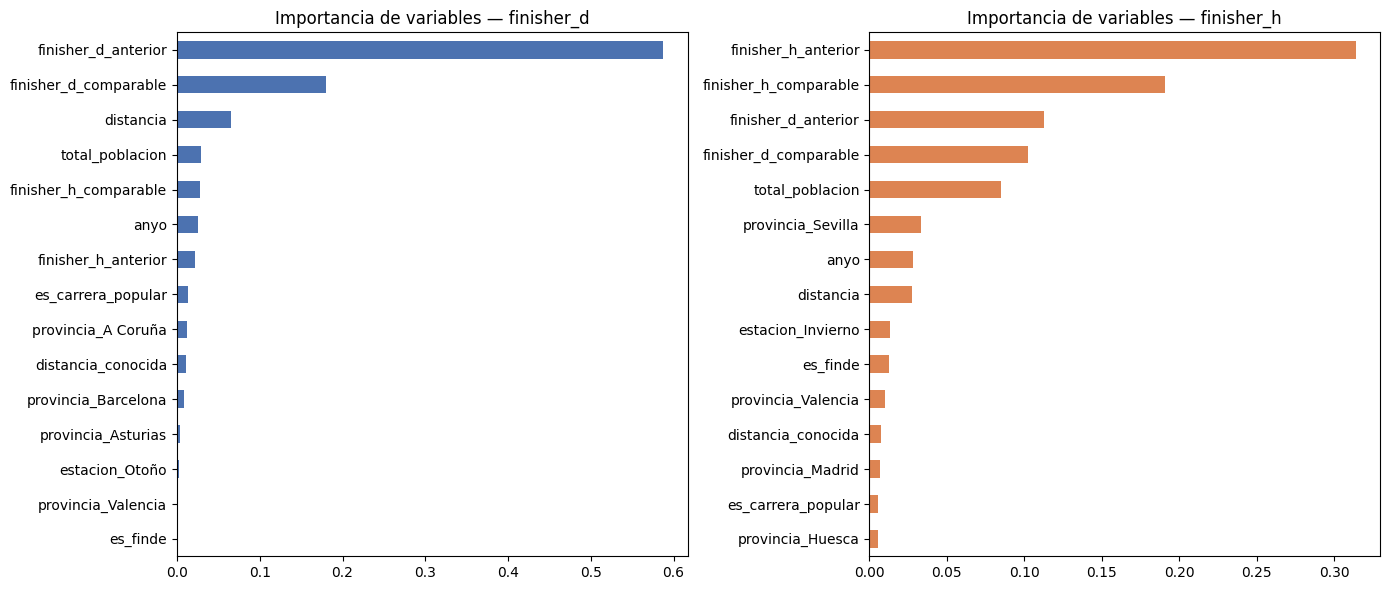

In [13]:
def importancias(modelo, nombre):
    imp = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(f"Top 15 variables más importantes para {nombre}:")
    print(imp.head(15).to_string())
    print()
    return imp


imp_d = importancias(rf_d, "finisher_d")
imp_h = importancias(rf_h, "finisher_h")

for nombre, imp in [("finisher_d", imp_d), ("finisher_h", imp_h)]:
    pos = list(imp.index).index("total_poblacion") + 1
    print(f"'total_poblacion' en {nombre}: puesto {pos} de {len(imp)}, "
          f"importancia={imp['total_poblacion']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp_d.head(15).sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Importancia de variables — finisher_d")
imp_h.head(15).sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Importancia de variables — finisher_h")
plt.tight_layout()
plt.show()

## ¿Cuánto depende todo esto de tener historial?

El historial de la edición anterior es, con diferencia, el predictor más fuerte. Vale
la pena separar el rendimiento en test entre carreras que sí tienen historial (la
mayoría de los casos "fáciles") y las que no (carreras nuevas o con un hueco de años,
donde el modelo tiene que apoyarse solo en `distancia`/`publico`/`población`/etc.) —
es el escenario donde de verdad se pone a prueba si esas variables descriptivas
aportan algo.

In [14]:
print("Test — SOLO carreras CON historial de la edición anterior:")
evaluar(y_d_test[tiene_hist_test], pred_d[tiene_hist_test], "finisher_d")
evaluar(y_h_test[tiene_hist_test], pred_h[tiene_hist_test], "finisher_h")

print()
print("Test — SOLO carreras SIN historial (nuevas o con hueco de años):")
evaluar(y_d_test[~tiene_hist_test], pred_d[~tiene_hist_test], "finisher_d")
evaluar(y_h_test[~tiene_hist_test], pred_h[~tiene_hist_test], "finisher_h")

Test — SOLO carreras CON historial de la edición anterior:
  finisher_d: MAE=  48.9   RMSE= 174.9   R²=0.322
  finisher_h: MAE=  92.0   RMSE= 217.7   R²=0.517

Test — SOLO carreras SIN historial (nuevas o con hueco de años):
  finisher_d: MAE=  44.0   RMSE= 205.0   R²=0.051
  finisher_h: MAE=  86.0   RMSE= 325.9   R²=0.215


(85.96069436992946, 325.8788041871429, 0.2154662027590617)

## ¿Importa que la carrera esté marcada como `es_carrera_popular`?

`es_carrera_popular` llega ya calculado desde `Limpieza_union.ipynb` (marca las categorías
Absoluta-General de `road running`/`trail running`) y ya se ha incluido como feature real
del modelo (sección "Construcción de `X`/`y`"), en vez de dejarla solo para segmentar la
evaluación a posteriori. Aquí se comprueba si el random forest final predice mejor o peor
sobre las carreras populares que sobre el resto del test, y si el efecto es solo un reflejo
de tener más historial (las carreras populares suelen llevar más años scrapeadas) o algo
adicional.

In [15]:
populares_test = modelo_df.loc[test_mask, "es_carrera_popular"].to_numpy()

print(f"Test — SOLO carreras populares ({populares_test.sum()} filas):")
evaluar(y_d_test[populares_test], pred_d[populares_test], "finisher_d")
evaluar(y_h_test[populares_test], pred_h[populares_test], "finisher_h")

print()
print(f"Test — SOLO carreras NO populares ({(~populares_test).sum()} filas):")
evaluar(y_d_test[~populares_test], pred_d[~populares_test], "finisher_d")
evaluar(y_h_test[~populares_test], pred_h[~populares_test], "finisher_h")

print()
print(f"Populares CON historial ({(populares_test & tiene_hist_test).sum()} filas):")
mask = populares_test & tiene_hist_test
evaluar(y_d_test[mask], pred_d[mask], "finisher_d")
evaluar(y_h_test[mask], pred_h[mask], "finisher_h")

print()
print(f"Populares SIN historial ({(populares_test & ~tiene_hist_test).sum()} filas):")
mask = populares_test & ~tiene_hist_test
evaluar(y_d_test[mask], pred_d[mask], "finisher_d")
evaluar(y_h_test[mask], pred_h[mask], "finisher_h")

Test — SOLO carreras populares (1954 filas):
  finisher_d: MAE=  55.9   RMSE= 148.8   R²=0.328
  finisher_h: MAE=  89.5   RMSE= 265.1   R²=0.356

Test — SOLO carreras NO populares (7174 filas):
  finisher_d: MAE=  43.2   RMSE= 204.3   R²=0.126
  finisher_h: MAE=  88.0   RMSE= 294.4   R²=0.302

Populares CON historial (863 filas):
  finisher_d: MAE=  59.6   RMSE= 128.7   R²=0.575
  finisher_h: MAE=  96.0   RMSE= 245.4   R²=0.518

Populares SIN historial (1091 filas):
  finisher_d: MAE=  52.9   RMSE= 163.0   R²=0.047
  finisher_h: MAE=  84.3   RMSE= 279.7   R²=0.186


(84.30803128792314, 279.6732221297261, 0.18552554878016103)

El modelo explica bastante más varianza en carreras populares que en el resto —
sobre todo en `finisher_d` (R²≈0.36 frente a ≈0.12) — aunque el MAE salga algo peor:
son carreras con cifras más grandes y variables, así que el error absoluto también lo
es; en términos relativos el modelo las entiende mejor.

Cruzándolo con `tiene_historial` se ve que el efecto **no es solo un reflejo de tener
más historial**: dentro de las carreras populares, seguir teniendo historial propio
marca una diferencia enorme (R²≈0.57 con historial frente a ≈0.11 sin él en
`finisher_d`) — el mejor resultado de todo el notebook. Para una carrera popular
**nueva** (sin historial), el modelo sigue flaqueando casi igual que en el caso
general: ser popular no arregla el problema de "carrera nueva".

Conclusión práctica: `es_carrera_popular` sí aporta señal real, no solo indirecta a
través del historial. Como siguiente paso se prueba, en la sección siguiente, un
modelo específico entrenado solo con Absoluta-General `road running`/`trail running`
(el segmento donde se concentran las carreras populares), tal como ya apuntaban las
notas iniciales.

## Modelo específico para Absoluta-General road running/trail running

Las notas iniciales y la sección anterior apuntan en la misma dirección: las carreras
populares se concentran en `road running`/`trail running` + `publico == "Absoluta/General"`
(20.013 de las 39.109 filas de `modelo_df`, un 51%), y ese segmento se comporta de forma
distinta al resto (infantil, veteranos, marcha, ciclismo...). Aquí se entrena un random
forest **solo con ese segmento** — mismo pipeline, mismo split temporal (train ≤2023,
test 2024-2025), mismo ajuste de hiperparámetros por walk-forward — para ver si
especializar el modelo mejora sobre usar el modelo general y evaluarlo únicamente en
ese mismo subconjunto de test.

In [16]:
modelo_seg = modelo_df[
    modelo_df["tipo_modalidad"].isin(["road running", "trail running"])
    & (modelo_df["publico"] == "Absoluta/General")
].copy()

X_seg = pd.get_dummies(modelo_seg[FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT], columns=FEATURES_CAT)
y_d_seg = modelo_seg["finisher_d"]
y_h_seg = modelo_seg["finisher_h"]

anyo_seg = modelo_seg["anyo"]
train_mask_seg = (anyo_seg <= 2023).to_numpy()
test_mask_seg = anyo_seg.isin([2024, 2025]).to_numpy()

X_train_seg, X_test_seg = X_seg[train_mask_seg], X_seg[test_mask_seg]
y_d_train_seg, y_d_test_seg = y_d_seg[train_mask_seg], y_d_seg[test_mask_seg]
y_h_train_seg, y_h_test_seg = y_h_seg[train_mask_seg], y_h_seg[test_mask_seg]

print(f"Segmento Absoluta-General road/trail running: {len(modelo_seg)} filas "
      f"({100 * len(modelo_seg) / len(modelo_df):.1f}% del total)")
print(f"Train (años <= 2023): {train_mask_seg.sum()} filas")
print(f"Test (años 2024-2025): {test_mask_seg.sum()} filas")

mediana_d_train_seg = y_d_train_seg.median()
mediana_h_train_seg = y_h_train_seg.median()
tiene_hist_test_seg = modelo_seg.loc[test_mask_seg, "tiene_historial"].to_numpy()
baseline_d_test_seg = np.where(tiene_hist_test_seg, modelo_seg.loc[test_mask_seg, "finisher_d_anterior"], mediana_d_train_seg)
baseline_h_test_seg = np.where(tiene_hist_test_seg, modelo_seg.loc[test_mask_seg, "finisher_h_anterior"], mediana_h_train_seg)

print()
print("Baseline del segmento (histórico del año anterior, o mediana de train del segmento si no hay):")
evaluar(y_d_test_seg, baseline_d_test_seg, "finisher_d")
evaluar(y_h_test_seg, baseline_h_test_seg, "finisher_h")

Segmento Absoluta-General road/trail running: 20013 filas (51.2% del total)
Train (años <= 2023): 14436 filas
Test (años 2024-2025): 4598 filas

Baseline del segmento (histórico del año anterior, o mediana de train del segmento si no hay):
  finisher_d: MAE=  75.8   RMSE= 266.0   R²=0.093
  finisher_h: MAE= 160.0   RMSE= 470.9   R²=-0.076


(160.0391474554154, 470.9072107442468, -0.0757793284783197)

In [17]:
anyo_train_arr_seg = modelo_seg.loc[train_mask_seg, "anyo"].to_numpy()
anyos_candidatos_seg = sorted(
    y for y in np.unique(anyo_train_arr_seg) if (anyo_train_arr_seg == y).sum() >= MIN_FILAS_ANYO_VALIDACION
)

cv_walk_forward_seg = []
for anyo_val in anyos_candidatos_seg:
    idx_val = np.where(anyo_train_arr_seg == anyo_val)[0]
    idx_train = np.where(anyo_train_arr_seg < anyo_val)[0]
    if len(idx_train) >= MIN_FILAS_ANYO_VALIDACION:
        cv_walk_forward_seg.append((anyo_val, idx_train, idx_val))
cv_walk_forward_seg = cv_walk_forward_seg[-MAX_PLIEGUES:]
print(f"Pliegues walk-forward (segmento): validando en los años {[a for a, _, _ in cv_walk_forward_seg]}")
cv_walk_forward_seg = [(idx_train, idx_val) for _, idx_train, idx_val in cv_walk_forward_seg]


def buscar_mejores_parametros_seg(X_tr, y_tr, nombre):
    busqueda = GridSearchCV(
        RandomForestRegressor(random_state=0, n_jobs=1),
        PARAM_GRID,
        cv=cv_walk_forward_seg,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    busqueda.fit(X_tr, y_tr)
    print(f"Mejores hiperparámetros para {nombre} (segmento): {busqueda.best_params_} "
          f"(MAE walk-forward: {-busqueda.best_score_:.1f})")
    return busqueda.best_params_


mejores_d_seg = buscar_mejores_parametros_seg(X_train_seg, y_d_train_seg, "finisher_d")
mejores_h_seg = buscar_mejores_parametros_seg(X_train_seg, y_h_train_seg, "finisher_h")

rf_d_seg = RandomForestRegressor(random_state=0, n_jobs=-1, **mejores_d_seg)
rf_d_seg.fit(X_train_seg, y_d_train_seg)
pred_d_seg = rf_d_seg.predict(X_test_seg)

rf_h_seg = RandomForestRegressor(random_state=0, n_jobs=-1, **mejores_h_seg)
rf_h_seg.fit(X_train_seg, y_h_train_seg)
pred_h_seg = rf_h_seg.predict(X_test_seg)

print()
print("Random forest específico del segmento (hiperparámetros ajustados):")
evaluar(y_d_test_seg, pred_d_seg, "finisher_d")
evaluar(y_h_test_seg, pred_h_seg, "finisher_h")

imp_d_seg = pd.Series(rf_d_seg.feature_importances_, index=X_seg.columns).sort_values(ascending=False)
imp_h_seg = pd.Series(rf_h_seg.feature_importances_, index=X_seg.columns).sort_values(ascending=False)
print()
print("Top 10 variables — finisher_d (segmento):")
print(imp_d_seg.head(10).to_string())
print()
print("Top 10 variables — finisher_h (segmento):")
print(imp_h_seg.head(10).to_string())

Pliegues walk-forward (segmento): validando en los años [2019, 2020, 2021, 2022, 2023]
Mejores hiperparámetros para finisher_d (segmento): {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300} (MAE walk-forward: 133.7)
Mejores hiperparámetros para finisher_h (segmento): {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 150} (MAE walk-forward: 131.6)

Random forest específico del segmento (hiperparámetros ajustados):
  finisher_d: MAE=  66.4   RMSE= 257.0   R²=0.154
  finisher_h: MAE= 125.6   RMSE= 381.8   R²=0.293

Top 10 variables — finisher_d (segmento):
finisher_d_anterior      0.596104
finisher_d_comparable    0.113279
distancia                0.069532
total_poblacion          0.048210
anyo                     0.046042
finisher_h_comparable    0.027168
provincia_Barcelona      0.026725
finisher_h_anterior      0.019307
es_carrera_popular       0.015823
provincia_A Coruña       0.015485

Top 10 variables — finisher_h (segmento):
finisher_h_anterior      0.345989
f

In [18]:
# Comparativa justa: el modelo GENERAL (entrenado con todas las categorías) evaluado
# solo en este mismo subconjunto de test, frente al modelo ESPECÍFICO entrenado solo con él.
es_seg_test = (
    modelo_df.loc[test_mask, "tipo_modalidad"].isin(["road running", "trail running"]).to_numpy()
    & (modelo_df.loc[test_mask, "publico"] == "Absoluta/General").to_numpy()
)

print(f"Mismo subconjunto de test ({es_seg_test.sum()} filas):")
print()
print("Modelo GENERAL evaluado solo en este segmento:")
evaluar(y_d_test[es_seg_test], pred_d[es_seg_test], "finisher_d")
evaluar(y_h_test[es_seg_test], pred_h[es_seg_test], "finisher_h")

print()
print("Modelo ESPECÍFICO (entrenado solo con este segmento):")
evaluar(y_d_test_seg, pred_d_seg, "finisher_d")
evaluar(y_h_test_seg, pred_h_seg, "finisher_h")

Mismo subconjunto de test (4598 filas):

Modelo GENERAL evaluado solo en este segmento:
  finisher_d: MAE=  66.2   RMSE= 257.9   R²=0.148
  finisher_h: MAE= 123.1   RMSE= 378.3   R²=0.306

Modelo ESPECÍFICO (entrenado solo con este segmento):
  finisher_d: MAE=  66.4   RMSE= 257.0   R²=0.154
  finisher_h: MAE= 125.6   RMSE= 381.8   R²=0.293


(125.57489816950083, 381.8087579370213, 0.2927966883020613)

**Especializar no mejora nada sobre el modelo general.** Evaluados en el mismo
subconjunto de test (4.598 filas), el modelo específico prácticamente empata con el
general: `finisher_d` mejora un poco (R²=0.148 → 0.154) pero `finisher_h` empeora
ligeramente (R²=0.306 → 0.293). Tiene sentido: el random forest general ya puede
separar `tipo_modalidad`/`publico` mediante las columnas one-hot, así que no hay mucha
señal adicional que ganar por entrenar aparte — y al partir los datos en dos, el
modelo específico entrena con menos ejemplos (14.436 filas de train frente a 28.084),
lo que probablemente explica el ligero empeoramiento en `finisher_h`.

Conclusión práctica: **no merece la pena mantener un modelo separado** para
Absoluta-General road running/trail running — el modelo único, con `es_carrera_popular`
como feature, ya captura lo que hay que capturar de ese segmento.

## Notas finales

- El baseline "este año = el año anterior" ya es fuerte por sí solo (confirma la
  correlación de 0.90 del EDA); el valor real del random forest hay que juzgarlo sobre
  todo en el subconjunto **sin** historial, y comparando siempre contra ese baseline,
  no contra "acertar el número exacto".
- La imputación de `total_poblacion` (16.6% de las filas) y de `distancia` (por el
  centinela `0`) es una limitación real heredada de los datos de origen — antes de fiarse
  de la importancia de esas variables conviene tener en cuenta que una parte de sus
  valores son "rellenos", no observaciones.
- El problema de las carreras de ciclismo de fondo mal etiquetadas como `road running`
  (`Mallorca 312`, `MOZARABE BIKE RACE`...) se corrigió en origen, en
  `Limpieza_sportmaniacs.ipynb`/`Limpieza_cruzandolameta.ipynb`, y `DF_TODAS_UNION.csv` ya
  incorpora la corrección — no hace falta ningún ajuste aquí.
- Los hiperparámetros del random forest ya se ajustan con validación walk-forward por
  año (ver sección anterior), no con un `GridSearchCV` de k-fold aleatorio.
- Para las carreras sin historial propio ya no se usa un único valor global: se estima
  por comparables (misma modalidad/público/provincia/distancia, con retroceso a grupos
  más amplios) — ver la sección "Para las carreras SIN historial". El rendimiento real
  de esta mejora hay que juzgarlo específicamente en el desglose "test sin historial"
  de más arriba, comparándolo con la versión anterior (mediana global).
- La fuente `rockthesport` (`Scraper_rockthesport.ipynb`) todavía no está integrada en
  `DF_TODAS_UNION.csv` — cuando lo esté, este notebook se puede volver a ejecutar sin
  cambios (parte siempre de `DF_TODAS_UNION.csv` recién generado).
- Próximo paso natural si se quiere seguir mejorando el caso "carrera nueva": usar
  variables geográficas más finas que `provincia` (comarca, o directamente distancia
  en km al evento comparable más cercano), ya que ahora mismo el retroceso a nivel
  "provincia" es bastante amplio en zonas con pocas carreras de una disciplina
  concreta.
- `es_carrera_popular` ya se usa como feature real del modelo. Se probó también un modelo específico para Absoluta-General `road running`/`trail running`, pero no mejora sobre el modelo general evaluado en ese mismo subconjunto (ver sección anterior) — no compensa mantenerlo aparte. El patrón de detección de `es_carrera_popular` (en `Limpieza_union.ipynb`) también se amplió (`nocturno/night`, `mujer/dona`, `milla urbana`, `legua`, `Sant Silvestre`, y una corrección de un patrón que se perdía carreras `SOLIDÀRIA` por un acento), pasando de 18.0% a 23.8% de las filas.